
--- 任务: 5.0deg (目标距离 556.0km) ---


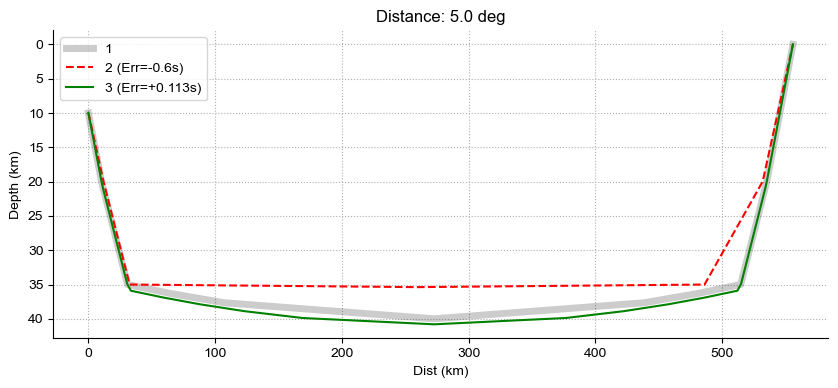

EFT 走时误差: 0.1126s

--- 任务: 45.0deg (目标距离 5003.8km) ---


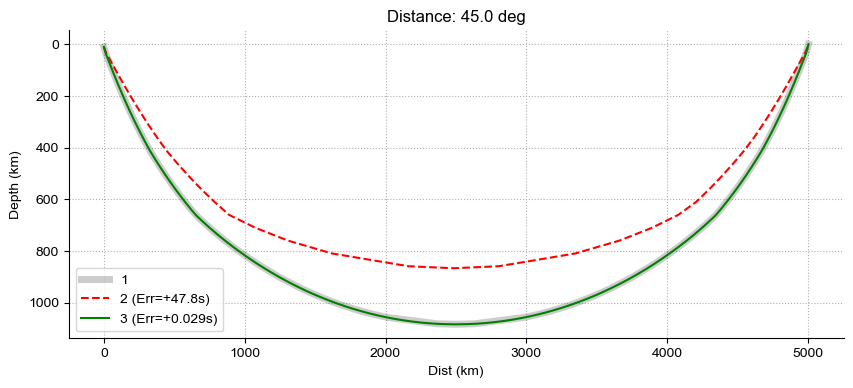

EFT 走时误差: 0.0285s


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from obspy.taup import TauPyModel
from scipy.optimize import brentq

# --- 1. 高精度模型准备 ---
R = 6371.0
# 定义 IASP91 关键点
# iasp91_d = np.array([0, 20, 35, 77.5, 120, 165, 210, 410, 660, 1000, 2000, 2889])
# iasp91_v = np.array([5.8, 5.8, 8.04, 8.045, 8.05, 8.175, 8.3, 9.03, 10.2, 11.5, 13.0, 13.69])

earth_model = r"./iasp91.nd"

def read_nd_model(filename):
    """
    读取 .nd 格式的一维速度模型文件，提取深度和P波速度。
    
    参数:
        filename (str): .nd 文件路径
        
    返回:
        depths (np.ndarray): 深度数组
        velocities (np.ndarray): P波速度数组
    """
    depths = []
    velocities = []
    
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            parts = line.split()
            try:
                # 尝试解析第一列和第二列为浮点数
                depth = float(parts[0])
                vp = float(parts[1])
                depths.append(depth)
                velocities.append(vp)
            except ValueError:
                # 如果抛出 ValueError，说明遇到了如 'mantle' 等非数字字符串，直接跳过
                continue
                
    return np.array(depths), np.array(velocities)


def build_dense_model(ds, vs, step=1.0):
    """构建高密度线性梯度模型，消除数值跳跃"""
    z_dense = np.arange(0, ds[-1] + step, step)
    v_dense = np.interp(z_dense, ds, vs)
    return z_dense, v_dense

# --- 2. 解析射线引擎 (处理线性梯度层) ---
def layer_step(p, v1, v2, z1, z2):
    """解析计算单一线性梯度层内的位移和走时"""
    dz = abs(z2 - z1)
    dv = v2 - v1
    if dz < 1e-9:
        return 0.0, 0.0
    if abs(dv) < 1e-9: # 常速层
        cos_i = np.sqrt(np.maximum(0, 1 - (p*v1)**2))
        if cos_i < 1e-10: return 1e4, 1e4 # 无法传播
        return dz * (p*v1)/cos_i, dz/(v1*cos_i)
    g = dv / dz # 速度梯度
    sqrt1 = np.sqrt(np.maximum(0, 1 - (p*v1)**2))
    sqrt2 = np.sqrt(np.maximum(0, 1 - (p*v2)**2))
    dx = (sqrt1 - sqrt2) / (p * g)
    dt = np.log((v2/v1) * (1 + sqrt1) / (1 + sqrt2)) / g
    return dx, dt

def trace_full(angle_deg, src_z, z_nodes, v_nodes):
    """追踪射线直到回到地表"""
    v_start = np.interp(src_z, z_nodes, v_nodes)
    p = np.sin(np.radians(angle_deg)) / v_start
    
    # 1. 下行阶段
    curr_x, curr_t = 0.0, 0.0
    path_x, path_z = [0.0], [src_z]
    
    start_idx = np.searchsorted(z_nodes, src_z)
    turning = False
    z_turn = 0
    
    for i in range(start_idx, len(z_nodes)-1):
        v1, v2 = v_nodes[i], v_nodes[i+1]
        z1, z2 = z_nodes[i], z_nodes[i+1]
        if i == start_idx: v1 = v_start; z1 = src_z
            
        if p * v2 >= 1.0: # 发生转折
            vt = 1.0 / p
            zt = z1 + (vt - v1) * (z2 - z1) / (v2 - v1)
            dx, dt = layer_step(p, v1, vt, z1, zt)
            #print("line92")
            curr_x += dx; curr_t += dt
            path_x.append(curr_x); path_z.append(zt)
            z_turn = zt
            turning = True
            break
        else:
            dx, dt = layer_step(p, v1, v2, z1, z2)
            #print("line100")
            curr_x += dx; curr_t += dt
            path_x.append(curr_x); path_z.append(z2)
            
    if not turning: return 1e7, 0, [], [] # 撞击地核

    # 2. 上行阶段 (对称性简化补全)
    # 实际地震学中，上行路径的 dx, dt 与下行路径在相同层内是相等的
    # 我们只需把路径反向叠加即可回到地表
    x_half = curr_x
    t_half = curr_t
    
    # 计算从 z_turn 回到地表 0 的路径
    # 这一部分包含：从 z_turn 回到 z1，再从 z1 逐层回到 0
    rev_nodes = z_nodes[z_nodes < z_turn][::-1]
    rev_nodes = np.concatenate(([z_turn], rev_nodes, [0]))
    rev_vs = np.interp(rev_nodes, z_nodes, v_nodes)
    
    for i in range(len(rev_nodes)-1):
        dx, dt = layer_step(p, rev_vs[i], rev_vs[i+1], rev_nodes[i], rev_nodes[i+1])
        #print("line120")
        curr_x += dx; curr_t += dt
        path_x.append(curr_x); path_z.append(rev_nodes[i+1])
        
    return curr_x, curr_t, np.array(path_x), np.array(path_z)

# --- 3. 稳健打靶法 ---
def robust_shooting(target_x, src_z, z_nodes, v_nodes):
    def obj(a):
        dist, _, _, _ = trace_full(a, src_z, z_nodes, v_nodes)
        return dist - target_x
    
    # 细粒度扫描变号区间 (1度一步)
    scan_as = np.linspace(1, 89, 90)
    for i in range(len(scan_as)-1):
        f1 = obj(scan_as[i])
        f2 = obj(scan_as[i+1])
        if f1 * f2 <= 0: # 发现变号区间
            best_a = brentq(obj, scan_as[i], scan_as[i+1])
            return trace_full(best_a, src_z, z_nodes, v_nodes)
            
    # 如果没找到，尝试扩大搜索范围或返回最近似
    return trace_full(45, src_z, z_nodes, v_nodes) # 回退方案

# --- 4. 主运行函数 ---
def compare(depth, dist_deg):
    target_x = np.radians(dist_deg) * R
    print(f"\n--- 任务: {dist_deg}deg (目标距离 {target_x:.1f}km) ---")
    
    # 1. 基准
    ref = TauPyModel(model="iasp91").get_ray_paths(depth, dist_deg, ["P"])[0]
    
    # 2. 直接直角 (Naive)
    # z_n, v_n = build_dense_model(iasp91_d, iasp91_v)
    z_n, v_n = read_nd_model(earth_model)
    # 过滤掉达到或超过地心半径的点，避免 R / (R - d) 产生除零错误
    valid_idx = z_n < R
    d_safe = z_n[valid_idx]
    v_safe = v_n[valid_idx]
    
    # 如果最深点被过滤了，可以手动添加一个极接近地心的点以保持模型完整性
    if z_n[-1] >= R:
        d_safe = np.append(d_safe, R - 1e-5)
        v_safe = np.append(v_safe, v_n[-1])
    
    z_n = d_safe
    v_n = v_safe
    
    d_x, d_t, d_px, d_pz = robust_shooting(target_x, depth, z_n, v_n)


    # 3. 展平变换 (EFT)
    z_f_nodes = R * np.log(R / (R - d_safe))
    v_f_nodes = v_safe * (R / (R - d_safe))
    z_f, v_f = build_dense_model(z_f_nodes, v_f_nodes)

    src_zf = R * np.log(R / (R - depth))
    e_x, e_t, e_px, e_pz = robust_shooting(target_x, src_zf, z_f, v_f)
    
    # EFT 还原
    e_px_s = e_px
    e_pz_s = R - R * np.exp(-e_pz / R)

    # 绘图
    plt.figure(figsize=(10, 4))
    plt.plot(ref.path['dist']*R, ref.path['depth'], 'k', lw=5, alpha=0.2, label='1')
    plt.plot(d_px, d_pz, 'r--', label=f'2 (Err={d_t-ref.time:+.1f}s)')
    plt.plot(e_px_s, e_pz_s, 'g-', label=f'3 (Err={e_t-ref.time:+.3f}s)')
    plt.gca().invert_yaxis()
    plt.legend(); plt.grid(ls=':'); plt.title(f"Distance: {dist_deg} deg")
    plt.xlabel("Dist (km)"); plt.ylabel("Depth (km)")
    plt.show()
    print(f"EFT 走时误差: {e_t - ref.time:.4f}s")

# 执行任务
compare(10.0, 5.0)
compare(10.0, 45.0)